In [2]:
import numpy as np
collision_details = eval("""{'start_points': array([[ 45.34980392, 137.6053772 ,   0.48783171],
       [ 38.34991455, 137.56622314,   0.48783171],
       [ 36.34994507, 137.55503845,   0.48783171],
       [ 47.34976959, 137.61656189,   0.48783171],
       [ 31.35002327, 137.52706909,   0.48783171],
       [ 52.34968948, 137.64453125,   0.48783171],
       [ 53.34967804, 137.65011597,   0.48783171],
       [ 41.34986877, 137.58300781,   0.48783171],
       [ 50.34972   , 137.63334656,   0.48783171],
       [ 50.34972   , 137.63334656,   0.48783171]]), 'end_points': array([[1.05759987e+02, 8.86133347e+01, 1.17813109e-03],
       [1.05695557e+02, 8.73649521e+01, 2.19440460e-03],
       [4.10268021e+01, 1.37598175e+02, 1.94099417e-03],
       [5.14092484e+01, 1.37629456e+02, 1.92871084e-03],
       [3.58949852e+01, 1.37571777e+02, 1.15005486e-03],
       [1.05706551e+02, 8.54981537e+01, 2.05715164e-03],
       [1.05989861e+02, 5.95546570e+01, 2.07256316e-03],
       [1.05795097e+02, 8.84222412e+01, 1.56669610e-03],
       [5.48495255e+01, 1.37684189e+02, 1.94717408e-03],
       [5.73784943e+01, 1.37673325e+02, 1.18209841e-03]]), 'speeds': array([4.27358426, 5.17666538, 5.07955891, 5.32522838, 4.82150856,
       5.23856132, 5.25140449, 5.04222513, 5.0832649 , 4.96522106]), 'collision_direction': array([143.11374405,  86.32987238, -86.76151978, -94.76955624,
       -41.68064101,  93.2547557 ,  88.01592311, -33.33801227,
       -84.37504628, -89.03576082])}
""".replace("array", "np.array"))

In [ ]:
collision_features = collision_details['end_points'][:, :2]
collision_features = np.concatenate((collision_features, collision_details['speeds'][:, np.newaxis], collision_details['collision_direction'][:, np.newaxis]), axis=1)

In [12]:
collision_features

array([[105.759987  ,  88.6133347 ,   4.27358426, 143.11374405],
       [105.695557  ,  87.3649521 ,   5.17666538,  86.32987238],
       [ 41.0268021 , 137.598175  ,   5.07955891, -86.76151978],
       [ 51.4092484 , 137.629456  ,   5.32522838, -94.76955624],
       [ 35.8949852 , 137.571777  ,   4.82150856, -41.68064101],
       [105.706551  ,  85.4981537 ,   5.23856132,  93.2547557 ],
       [105.989861  ,  59.554657  ,   5.25140449,  88.01592311],
       [105.795097  ,  88.4222412 ,   5.04222513, -33.33801227],
       [ 54.8495255 , 137.684189  ,   5.0832649 , -84.37504628],
       [ 57.3784943 , 137.673325  ,   4.96522106, -89.03576082]])

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

import pandas as pd

# root = '/home/guannan/Projects/SBT-data/InterFuser/2025-11-26|13:00:31/routes_short_11_26_13_43_25/'
# # os.listdir(root)


# # 'v.npy',
# # 'acc.npy',


# # control     = np.loadtxt(root+'control.csv')
# real_route  = pd.read_csv(root+'real_route.csv')
# ori_route   = pd.read_csv(root+'ori_route.csv')


def get_collision_details(fitness_dir):

    root = fitness_dir.replace('fitness.csv','')
    folders = os.listdir(root)
    folders.sort()
    folders = [folder for folder in folders if 'routes_' in folder ]
    start_points = []
    end_points = []
    speeds = []
    for folder in folders:
        real_route  = pd.read_csv(root+folder+'/real_route.csv').to_numpy()
        speeds.append(np.load(root+folder+'/v.npy')[-1])
        start_points.append(real_route[0]) 
        end_points.append(real_route[-1])
        

    fitness_header = ["DOL","DVE",'DVE-d',"DPD","DSM","DFD"]
    fitness = pd.read_csv(fitness_dir,names=fitness_header)
    fitness['DVE-d'] = fitness['DVE-d'].apply(lambda data: float(data[:-1]))

    collision_direction = fitness['DVE-d']

    collision_details = {
        'start_points': np.array(start_points),
        'end_points': np.array(end_points),
        'speeds': np.array(speeds),
        'collision_direction': np.array(collision_direction)
    }
    return collision_details

fitness_dir = '/home/guannan/Projects/SBT-data/InterFuser/2026-02-10|15:44:29/fitness.csv'
print(get_collision_details(fitness_dir))

{'start_points': array([[ 30.35004044, 137.52148438,   0.48783171],
       [ 25.35011864, 137.49351501,   0.48783171],
       [ 44.34981918, 137.59977722,   0.48783171],
       [ 35.34996033, 137.54945374,   0.48783171],
       [ 52.34968948, 137.64453125,   0.48783171],
       [ 37.34992981, 137.56063843,   0.48783171],
       [ 34.34997559, 137.54385376,   0.48783171],
       [ 38.34991455, 137.56622314,   0.48783171],
       [ 33.34999084, 137.53825378,   0.48783171],
       [ 44.34981918, 137.59977722,   0.48783171]]), 'end_points': array([[1.04800468e+02, 1.01768539e+02, 1.41448970e-03],
       [1.04307213e+02, 1.03796715e+02, 2.06138613e-03],
       [1.05908707e+02, 7.46121063e+01, 1.20265957e-03],
       [1.05667519e+02, 9.24414520e+01, 1.02687837e-03],
       [1.05791649e+02, 7.74595566e+01, 1.14238739e-03],
       [1.05811913e+02, 7.85217209e+01, 1.56368257e-03],
       [1.05803329e+02, 8.25845947e+01, 2.11143494e-03],
       [1.05612694e+02, 9.24072418e+01, 1.03950500e-03],
 

In [28]:
eval("""{'start_points': array([[ 30.35004044, 137.52148438,   0.48783171],
       [ 25.35011864, 137.49351501,   0.48783171],
       [ 44.34981918, 137.59977722,   0.48783171],
       [ 35.34996033, 137.54945374,   0.48783171],
       [ 52.34968948, 137.64453125,   0.48783171],
       [ 37.34992981, 137.56063843,   0.48783171],
       [ 34.34997559, 137.54385376,   0.48783171],
       [ 38.34991455, 137.56622314,   0.48783171],
       [ 33.34999084, 137.53825378,   0.48783171],
       [ 44.34981918, 137.59977722,   0.48783171]]), 'end_points': array([[1.04800468e+02, 1.01768539e+02, 1.41448970e-03],
       [1.04307213e+02, 1.03796715e+02, 2.06138613e-03],
       [1.05908707e+02, 7.46121063e+01, 1.20265957e-03],
       [1.05667519e+02, 9.24414520e+01, 1.02687837e-03],
       [1.05791649e+02, 7.74595566e+01, 1.14238739e-03],
       [1.05811913e+02, 7.85217209e+01, 1.56368257e-03],
       [1.05803329e+02, 8.25845947e+01, 2.11143494e-03],
       [1.05612694e+02, 9.24072418e+01, 1.03950500e-03],
       [1.05924072e+02, 6.76091080e+01, 1.16825104e-03],
       [1.04974640e+02, 1.00879799e+02, 1.57028192e-03]]), 'speeds': array([5.1832364 , 5.1238023 , 4.9490011 , 4.7403851 , 4.86959636,
       5.04923433, 5.2621563 , 4.79048227, 4.1685137 , 5.11546808]), 'collision_direction': array([  86.3924116 ,   88.22070916,   88.61511284,  -35.90214856,
         88.73532431, -164.62800821,   92.5869495 ,   82.30804595,
         84.32332691, -162.44080784])}""".replace('array','np.array'))

{'start_points': array([[ 30.35004044, 137.52148438,   0.48783171],
        [ 25.35011864, 137.49351501,   0.48783171],
        [ 44.34981918, 137.59977722,   0.48783171],
        [ 35.34996033, 137.54945374,   0.48783171],
        [ 52.34968948, 137.64453125,   0.48783171],
        [ 37.34992981, 137.56063843,   0.48783171],
        [ 34.34997559, 137.54385376,   0.48783171],
        [ 38.34991455, 137.56622314,   0.48783171],
        [ 33.34999084, 137.53825378,   0.48783171],
        [ 44.34981918, 137.59977722,   0.48783171]]),
 'end_points': array([[1.04800468e+02, 1.01768539e+02, 1.41448970e-03],
        [1.04307213e+02, 1.03796715e+02, 2.06138613e-03],
        [1.05908707e+02, 7.46121063e+01, 1.20265957e-03],
        [1.05667519e+02, 9.24414520e+01, 1.02687837e-03],
        [1.05791649e+02, 7.74595566e+01, 1.14238739e-03],
        [1.05811913e+02, 7.85217209e+01, 1.56368257e-03],
        [1.05803329e+02, 8.25845947e+01, 2.11143494e-03],
        [1.05612694e+02, 9.24072418e+01, 1

In [17]:
speeds

[5.183236395758718,
 5.123802300339416,
 4.949001095578322,
 4.740385099415126,
 4.869596364836649,
 5.049234333565799,
 5.262156295344036,
 4.790482271498768,
 4.168513695673418,
 5.115468078007807]

In [14]:
fitness['DVE-d'].to_numpy()

array([  86.3924116 ,   88.22070916,   88.61511284,  -35.90214856,
         88.73532431, -164.62800821,   92.5869495 ,   82.30804595,
         84.32332691, -162.44080784])

In [12]:
fitness

,DOL,DVE,DVE-d,DPD,DSM,DFD
0,0.532197,1.121340,86.392412,1000,62.385536,0.042105
1,0.520640,1.126553,88.220709,1000,62.347195,0.040816
2,0.897666,1.066047,88.615113,1000,40.701870,0.045872
3,0.532862,0.267680,-35.902149,1000,57.481361,0.040404
4,0.905938,1.062336,88.735324,1000,43.500904,0.041237
5,0.931830,0.064214,-164.628008,1000,44.532780,0.044643
6,0.940996,1.069370,92.586950,1000,48.508987,0.045455
7,0.527277,1.037921,82.308046,1000,57.416748,0.041667
8,0.870209,1.105510,84.323327,1000,33.929543,0.046875
9,0.527282,0.433201,-162.440808,1000,61.944096,0.037037


In [ ]:
fitness_header = ["DOL","DVE",'DVE-d',"DPD","DSM","DFD"]


fitness = pd.read_csv(fitness_dir,names=fitness_header)


,DOL,DVE,DVE-d,DPD,DSM,DFD
0,0.532197,(1.1213403940200806,86.39241160296459),1000,62.385536,0.042105
1,0.520640,(1.1265530586242676,88.22070915995968),1000,62.347195,0.040816
2,0.897666,(1.0660470724105835,88.61511283562278),1000,40.701870,0.045872
3,0.532862,(0.2676801383495331,-35.90214856209306),1000,57.481361,0.040404
4,0.905938,(1.062335729598999,88.73532430552946),1000,43.500904,0.041237
5,0.931830,(0.06421428918838501,-164.62800821066054),1000,44.532780,0.044643
6,0.940996,(1.0693703889846802,92.58694950024508),1000,48.508987,0.045455
7,0.527277,(1.0379207134246826,82.30804594815517),1000,57.416748,0.041667
8,0.870209,(1.1055095195770264,84.32332690583128),1000,33.929543,0.046875
9,0.527282,(0.43320131301879883,-162.4408078437764),1000,61.944096,0.037037


In [ ]:
pd.read_csv(fitness_dir,header=fitness_header)

,0.5321969372374192,(1.1213403940200806,86.39241160296459),1000,62.385536193847656,0.04210526315789476
0,0.520640,(1.1265530586242676,88.22070915995968),1000,62.347195,0.040816
1,0.897666,(1.0660470724105835,88.61511283562278),1000,40.701870,0.045872
2,0.532862,(0.2676801383495331,-35.90214856209306),1000,57.481361,0.040404
3,0.905938,(1.062335729598999,88.73532430552946),1000,43.500904,0.041237
4,0.931830,(0.06421428918838501,-164.62800821066054),1000,44.532780,0.044643
5,0.940996,(1.0693703889846802,92.58694950024508),1000,48.508987,0.045455
6,0.527277,(1.0379207134246826,82.30804594815517),1000,57.416748,0.041667
7,0.870209,(1.1055095195770264,84.32332690583128),1000,33.929543,0.046875
8,0.527282,(0.43320131301879883,-162.4408078437764),1000,61.944096,0.037037


In [33]:
folders

['routes_courve_02_10_15_44_45',
 'routes_courve_02_10_15_46_38',
 'routes_courve_02_10_15_48_41',
 'routes_courve_02_10_15_51_04',
 'routes_courve_02_10_15_52_52',
 'routes_courve_02_10_15_54_57',
 'routes_courve_02_10_15_57_25',
 'routes_courve_02_10_15_59_27',
 'routes_courve_02_10_16_01_28',
 'routes_courve_02_10_16_04_24']

In [15]:
def plot_route_compair(ori_route, real_route, section='Curve', width=False, title=''):
    plt.style.use('_mpl-gallery')

    # linewidth need to be changed accodring to the pix/m, but this figure is not find yet
    linewidth = (60,40) if width else (2,2)


    if section=='Curve':
        fig, ax = plt.subplots(figsize=(3, 5))

        ax.plot(ori_route['y'], ori_route['x'], linewidth=linewidth[0], label='Original Path')
        ax.plot(real_route['y'], real_route['x'], linewidth=linewidth[1], label='Real Path', color='orange')

        ax.set(xlim=(85, 145),  xticks=np.arange(90, 150, 10),
               ylim=(15, 115), yticks=np.arange(20, 120, 10))
        # plt.legend()
    elif section=='Straight':
        fig, ax = plt.subplots(figsize=(2, 5))

        ax.plot(ori_route['x'], ori_route['y'], linewidth=linewidth[0], label='Target Route')
        ax.plot(real_route['x'], real_route['y'], linewidth=linewidth[1], label='Real Route', color='orange')

        ax.set(xlim=(-88.5, -81.5),  xticks=np.arange(-88, -81, 1),
               ylim=(-115, 95), yticks=np.arange(-120, 91, 10))
        # plt.legend(loc=2)
    plt.title(title)
    plt.show()

In [18]:
real_route

,x,y,z
0,-85.192001,-119.918961,-0.177035
1,-85.191978,-119.918846,-0.165125
2,-85.191978,-119.918747,-0.155023
3,-85.191971,-119.918671,-0.147011
4,-85.191971,-119.918610,-0.140921
...,...,...,...
2282,-84.702087,50.895000,0.607198
2283,-84.700630,51.141220,0.613732
2284,-84.699356,51.392132,0.620573
2285,-84.698189,51.647625,0.627324


In [19]:
ori_route

,x,y,z
0,-85.192039,-119.918503,0.379761
1,-85.189308,-118.918510,-0.134153
2,-85.186584,-117.918510,-0.148828
3,-85.183853,-116.918518,-0.164265
4,-85.181129,-115.918518,-0.180463
...,...,...,...
177,-84.710732,56.560829,0.734246
178,-84.708000,57.560825,0.751191
179,-84.705276,58.560825,0.766563
180,-84.702553,59.560818,0.780362


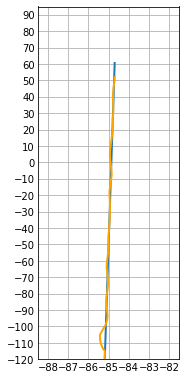

In [21]:
plot_route_compair(ori_route,real_route,section='Straight')

In [12]:
real_route

,x,y,z
0,-85.192001,-119.918961,-0.177035
1,-85.191978,-119.918846,-0.165125
2,-85.191978,-119.918747,-0.155023
3,-85.191971,-119.918671,-0.147011
4,-85.191971,-119.918610,-0.140921
...,...,...,...
2282,-84.702087,50.895000,0.607198
2283,-84.700630,51.141220,0.613732
2284,-84.699356,51.392132,0.620573
2285,-84.698189,51.647625,0.627324


In [13]:
ori_route

,x,y,z
0,-85.192039,-119.918503,0.379761
1,-85.189308,-118.918510,-0.134153
2,-85.186584,-117.918510,-0.148828
3,-85.183853,-116.918518,-0.164265
4,-85.181129,-115.918518,-0.180463
...,...,...,...
177,-84.710732,56.560829,0.734246
178,-84.708000,57.560825,0.751191
179,-84.705276,58.560825,0.766563
180,-84.702553,59.560818,0.780362


In [6]:
!pwd

/home/guannan/Projects/TCP-Interfuser/leaderboard/leaderboard/SBT


In [ ]:
from argparse import Namespace
import numpy as np
import os
def parse_fuzzing_arguments():
    # [ego_linear_speed, min_d, d_angle_norm, offroad_d, wronglane_d, dev_dist, is_offroad, is_wrong_lane, is_run_red_light, is_collision]
    default_objective_weights = np.array([-1., 1., 1., 1., 1., -1., 0., 0., 0., 0.])
    default_objectives = np.array([0., 20., 1., 7., 7., 0., 0., 0., 0., 0.])
    default_check_unique_coeff = [0, 0.1, 0.5]
    WARMUP_PATH = '<path-to-warm-up-run-folder>'

    fuzzing_arguments = Namespace(
        # general
        route_type='town07_front_0',
        scenario_type='go_straight_town07',
        ego_car_model='lbc',  # 默认值，未在命令行指定
        algorithm_name='nsga2-un',
        
        ports=[2021],  # -p 2021
        scheduler_port=8795,  # -s 8795
        dashboard_address=8796,  # -d 8796
        
        simulator='carla',  # 默认值，未在命令行指定
        random_seed=0,  # 默认值

        # carla specific
        has_display='0',  # --has_display 0
        debug=1,  # 默认值
        correct_spawn_locations_after_run=0,  # 默认值
        
        # carla_op specific
        carla_path="../carla_0911_rss/CarlaUE4.sh",  # 默认值

        # no_simulation specific
        no_simulation_data_path=None,  # 默认值
        objective_labels=[],  # 默认值
        
        # logistic
        root_folder='carla_lbc/run_results',  # 默认值
        parent_folder='',  # 默认值
        mean_objectives_across_generations_path='',  # 默认值
        episode_max_time=60,  # 默认值
        record_every_n_step=5,  # --record_every_n_step 5
        gpus='0,1',  # 默认值

        # algorithm related
        n_gen=15,  # --n_gen 15
        pop_size=50,  # --pop_size 50
        survival_multiplier=1,  # 默认值
        n_offsprings=300,  # 默认值
        has_run_num=700,  # --has_run_num 700
        sample_multiplier=200,  # 默认值
        mating_max_iterations=200,  # 默认值
        only_run_unique_cases=1,  # --only_run_unique_cases 1
        consider_interested_bugs=1,  # 默认值

        outer_iterations=3,  # 默认值
        objective_weights=np.array([-1., 1., 1., 0., 0., 0., 0., 0., 0., 0.]),  # --objective_weights -1 1 1 0 0 0 0 0 0 0
        default_objectives=default_objectives,  # 默认值
        standardize_objective=0,  # 默认值
        normalize_objective=0,  # 默认值
        traj_dist_metric='nearest',  # 默认值

        check_unique_coeff=[0, 0.1, 0.5],  # --check_unique_coeff 0 0.1 0.5
        use_single_objective=1,  # 默认值
        rank_mode='adv_nn',  # --rank_mode adv_nn
        ranking_model='nn_pytorch',  # 默认值
        initial_fit_th=100,  # 默认值
        min_bug_num_to_fit_dnn=10,  # 默认值

        pgd_eps=1.01,  # 默认值
        adv_conf_th=-4,  # 默认值
        attack_stop_conf=0.9,  # 默认值
        use_single_nn=1,  # 默认值

        warm_up_path=WARMUP_PATH,  # --warm_up_path <path-to-warm-up-run-folder>
        warm_up_len=500,  # --warm_up_len 500
        regression_nn_use_running_data=1,  # 默认值

        sample_avoid_ego_position=0,  # 默认值
        
        uncertainty='',  # 默认值
        model_type='one_output',  # 默认值
        
        termination_condition='generations',  # 默认值
        max_running_time=3600*24,  # 默认值
        
        emcmc=0,  # 默认值
        use_unique_bugs=1,  # 默认值
        finish_after_has_run=1  # 默认值
    )

    os.environ['HAS_DISPLAY'] = fuzzing_arguments.has_display
    os.environ['CUDA_VISIBLE_DEVICES'] = fuzzing_arguments.gpus
    fuzzing_arguments.objective_weights = np.array(fuzzing_arguments.objective_weights)
    # ['BNN', 'one_output']
    # BALD and BatchBALD only support BNN
    if fuzzing_arguments.uncertainty.split('_')[0] in ['BALD', 'BatchBALD']:
        fuzzing_arguments.model_type = 'BNN'

    if 'un' in fuzzing_arguments.algorithm_name:
        fuzzing_arguments.use_unique_bugs = 1
    else:
        fuzzing_arguments.use_unique_bugs = 0

    if fuzzing_arguments.algorithm_name in ['nsga2-emcmc', 'nsga2-un-emcmc']:
        fuzzing_arguments.emcmc = 1
    else:
        fuzzing_arguments.emcmc = 0

    return fuzzing_arguments


In [13]:
np.zeros(71)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [9]:
a = parse_fuzzing_arguments()

In [12]:
a.emcmc

0

In [1]:
warm_up_path = 'asdasd'
dt = None
cumulative_info = None

In [2]:
(warm_up_path and 
 ((dt and not cumulative_info) or 
  (not dt)))

True

In [10]:
(dt and not cumulative_info) or (not dt)

True

In [4]:
np.arange(1,21)*0.05

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

array([[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       [0.1 , 0.1 , 0.1 , ..., 0.1 , 0.1 , 0.1 ],
       ...,
       [0.85, 0.85, 0.85, ..., 0.85, 0.85, 0.85],
       [0.9 , 0.9 , 0.9 , ..., 0.9 , 0.9 , 0.9 ],
       [0.95, 0.95, 0.95, ..., 0.95, 0.95, 0.95]])

: 

In [5]:
import os
import sys
import time
import datetime
import traceback
import subprocess
import numpy as np
import pandas as pd

from utils import get_one_fitness, LargeScenario

def str_to_timestamp(time_str, format="%Y-%m-%d|%H:%M:%S"):
    return time.mktime(time.strptime(time_str[:19], "%Y-%m-%d|%H:%M:%S"))

def filt_folders(folders, start_time, end_time):
    start_timestamp =  str_to_timestamp(start_time)
    end_timestamp =  str_to_timestamp(end_time)
    result = []
    for folder in folders:
        if str_to_timestamp(folder) >= start_timestamp and str_to_timestamp(folder) <= end_timestamp:
            result.append(folder)
    return result

root = '/home/guannan/Projects/SBT-data/InterFuser'
folders = os.listdir(root)
folders.sort()
# folders = filt_folders(folders, '2025-02-17|16:00:00', '2025-02-18|03:50:00')
folders = filt_folders(folders, '2025-10-29|00:00:00', '2025-10-31|03:50:00')

fitnesses = []
scenarios = []

for folder in folders:
    path = "{}/{}/".format(root, folder)
    print(path)
    fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
    scenarios.append(LargeScenario(path))

/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|21:23:01/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|22:03:02/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|22:28:35/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|22:57:35/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|23:21:16/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-29|23:39:35/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|00:04:20/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|00:28:02/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|00:51:05/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|01:12:44/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|01:32:16/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|01:50:39/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|02:17:29/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|02:41:25/
/home/guannan/Projects/SBT-data/InterFuser/2025-10-30|03:00:09/
/home/guannan/Projects/SBT-data/InterFus

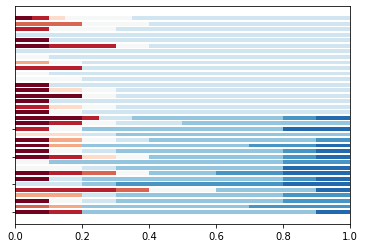

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def shift_data(data):
    shift_data = data+0.09999999999999
    shift_data[shift_data>1]=1
    return shift_data


cmap = mpl.cm.RdBu
colors = cmap(range(3,253,25))

# fig, axs = plt.subplots(1, 6, figsize=(22, 4), sharey=True)

fig, ax = plt.subplots()

stack_hist_discrete = np.concatenate([ 
    [np.histogram(shift_data(fitness), range=(0,1), bins=10)[0]/fitness.shape[0]]
    for fitness in fitnesses
])

length = len(stack_hist_discrete)

left = np.zeros(length)
for i in range(10):
    ax.barh(y = (length-1)*0.2-np.arange(length)*0.2, width = stack_hist_discrete[:,i], left=left, color = colors[i], height=0.14)
    left += stack_hist_discrete[:,i]
plt.yticks(range(4), ['' for _ in range(4)])
plt.show()


In [7]:
X = np.array([])
for scenario in scenarios:
    if len(X) == 0:
        X = scenario.data
    else:
        X = np.concatenate([X, scenario.data], axis=0)

y = np.array([])
for fitnesse in fitnesses:
    if len(y) == 0:
        y = fitnesse.data
    else:
        y = np.concatenate([y, fitnesse], axis=0)

X.shape, y.shape

((380, 71), (380,))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
import numpy as np

# 定义小型神经网络
class SmallNet(nn.Module):
    def __init__(self, input_dim):
        super(SmallNet, self).__init__()
        self.fc_64   = nn.Linear(input_dim, 64) # 第一层，全连接
        self.relu    = nn.ReLU()                # ReLU 激活函数
        self.dropout = nn.Dropout(0.1)          # Dropout 防止过拟合
        self.fc_32   = nn.Linear(64, 32)        # 第二层，全连接
        self.fc_out  = nn.Linear(32, 1)         # 输出层，单个回归值

    def forward(self, x):
        x = self.fc_64(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc_32(x)
        x = self.relu(x)

        x = self.fc_out(x)
        return torch.sigmoid(x)  # 输出值在 0-1 范围内

# 自定义加权损失函数
def weighted_mse_loss(output, target):
    # y=0 的样本权重更高
    weights = torch.where(target == 0, 5.0, 1.0)
    # weights = torch.where(target < 0.1, (1-target)*10, 1.0)
    # weights = torch.where(target < 0.5, 1-target, target)
    # weights = torch.where(target < 0.1, 1.0, 1.0)
    loss = weights * (output - target) ** 2
    return loss.mean()

def pairwise_rank_loss(output, target):
    # 计算目标值和预测值的差
    diff_target = target - target.T  # Target 的差
    diff_output = output - output.T  # Output 的差

    # 计算排序损失：如果 diff_target 和 diff_output 符号不一致，则 penalize
    loss = torch.mean(torch.relu(-diff_target * diff_output))  # relu 确保非负
    return loss

def combined_loss(output, target):
    weights = [10,0]
    return (weights[0]*weighted_mse_loss(output, target) + weights[1]*pairwise_rank_loss(output, target))/sum(weights)

In [58]:
# 数据集（占位）
# 使用你的数据，替换 X 和 y
# X: shape = (num_samples, 71), y: shape = (num_samples,)
X = X.astype(np.float32)  # 随机生成特征
y = y.astype(np.float32)     # 随机生成标签

# 转换为 PyTorch 张量
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y).view(-1, 1)

# 超参数
input_dim = X.shape[1]
batch_size = 16
num_epochs = 100
learning_rate = 0.001

# K 折交叉验证
kf = KFold(n_splits=5)
fold_mse = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}")
    
    # 划分训练集和验证集
    X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
    y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
    
    # 数据加载器
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化模型、损失函数和优化器
    model = SmallNet(input_dim=input_dim)
    # criterion = weighted_mse_loss
    # criterion = pairwise_rank_loss
    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 训练模型
    best_val_loss = float('inf')
    best_val_mse_loss = float('inf')
    early_stop_counter = 0
    patience = 10
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证模型
        model.eval()
        val_loss = 0.0
        val_mse_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_mse_loss += weighted_mse_loss(outputs, y_batch).item()
        
        val_loss /= len(val_loader)
        val_mse_loss /= len(val_loader)
        # print(f"Epoch {epoch + 1}: Train Loss = {train_loss / len(train_loader):.4f}, Val Loss = {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mse_loss = val_mse_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print("Early stopping triggered!")
                break
    
    # 保存每折的验证损失
    # fold_mse.append(best_val_loss)
    fold_mse.append(best_val_mse_loss)

# 打印结果
print("Cross-Validation MSE:", np.mean(fold_mse))
print("Cross-Validation MSE:", np.mean(fold_mse)**0.5)
print(np.concatenate([np.array(outputs), np.array(y_batch)], axis=1))

Fold 1
Early stopping triggered!
Fold 2
Early stopping triggered!
Fold 3
Early stopping triggered!
Fold 4
Early stopping triggered!
Fold 5
Early stopping triggered!
Cross-Validation MSE: 0.0026355294874520043
Cross-Validation MSE: 0.05133740826582507
[[0.46371144 0.5352794 ]
 [0.39983362 0.5183008 ]]


In [154]:
import random
random.random()

0.04251749085949408

In [84]:
import os
import time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold, train_test_split

from utils import get_one_fitness, LargeScenario

def str_to_timestamp(time_str, format="%Y-%m-%d|%H:%M:%S"):
    return time.mktime(time.strptime(time_str[:19], "%Y-%m-%d|%H:%M:%S"))

def filt_folders(folders, start_time, end_time):
    start_timestamp =  str_to_timestamp(start_time)
    end_timestamp =  str_to_timestamp(end_time)
    result = []
    for folder in folders:
        if str_to_timestamp(folder) >= start_timestamp and str_to_timestamp(folder) <= end_timestamp:
            result.append(folder)
    return result

def load_data(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    # root = '/home/guannan/Projects/SBT-data/InterFuser'
    folders = os.listdir(root)
    folders.sort()
    folders = filt_folders(folders, start, end)

    fitnesses = []
    scenarios = []

    for folder in folders:
        path = "{}/{}/".format(root, folder)
        # print(path)
        fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
        scenarios.append(LargeScenario(path))
    
    X = np.array([])
    for scenario in scenarios:
        if len(X) == 0:
            X = scenario.data
        else:
            X = np.concatenate([X, scenario.data], axis=0)

    y = np.array([])
    for fitnesse in fitnesses:
        if len(y) == 0:
            y = fitnesse
        else:
            y = np.concatenate([y, fitnesse], axis=0)
    return X, y


# 定义小型神经网络
class SmallNet(nn.Module):
    def __init__(self, input_dim):
        super(SmallNet, self).__init__()
        # self.fc_64   = nn.Linear(input_dim, 64) # 第一层，全连接
        # self.relu    = nn.ReLU()                # ReLU 激活函数
        # self.dropout = nn.Dropout(0.1)          # Dropout 防止过拟合
        # self.fc_32   = nn.Linear(64, 32)        # 第二层，全连接
        # self.fc_out  = nn.Linear(32, 1)         # 输出层，单个回归值
        self.fc_64   = nn.Linear(input_dim, 128)  # 第一层，全连接
        self.relu    = nn.ReLU()                  # ReLU 激活函数
        self.dropout = nn.Dropout(0.1)            # Dropout 防止过拟合
        self.fc_32   = nn.Linear(128, 64)         # 第二层，全连接
        self.fc_out  = nn.Linear(64, 1)           # 输出层，单个回归值


    def forward(self, x):
        x = self.fc_64(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc_32(x)
        x = self.relu(x)

        x = self.fc_out(x)
        return torch.sigmoid(x)  # 输出值在 0-1 范围内

# 自定义加权损失函数
def weighted_mse_loss(output, target):
    # y=0 的样本权重更高
    weights = torch.where(target == 0, 5.0, 1.0)
    # weights = torch.where(target < 0.1, (1-target)*10, 1.0)
    # weights = torch.where(target < 0.5, 1-target, target)
    # weights = torch.where(target < 0.1, 1.0, 1.0)
    loss = weights * (output - target) ** 2
    return loss.mean()

def pairwise_rank_loss(output, target):
    # 计算目标值和预测值的差
    diff_target = target - target.T  # Target 的差
    diff_output = output - output.T  # Output 的差

    # 计算排序损失：如果 diff_target 和 diff_output 符号不一致，则 penalize
    loss = torch.mean(torch.relu(-diff_target * diff_output))  # relu 确保非负
    return loss

def combined_loss(output, target):
    weights = [10,0]
    return (weights[0]*weighted_mse_loss(output, target) + weights[1]*pairwise_rank_loss(output, target))/sum(weights)


def train(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    X, y = load_data(root, start, end)
    # 数据集（占位）
    # 使用你的数据，替换 X 和 y
    # X: shape = (num_samples, 71), y: shape = (num_samples,)
    X = X.astype(np.float32)  # 随机生成特征
    y = y.astype(np.float32)  # 随机生成标签

    # 转换为 PyTorch 张量
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y).view(-1, 1)

    # 超参数
    input_dim = X.shape[1]
    batch_size = 16
    num_epochs = 100
    learning_rate = 0.001

    # K 折交叉验证
    kf = KFold(n_splits=5)
    fold_mse = []


    X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.33, random_state=42)
    # for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        # print(f"Fold {fold + 1}")
        
        # # 划分训练集和验证集
        # X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
        # y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
        
    # 数据加载器
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化模型、损失函数和优化器
    model = SmallNet(input_dim=input_dim)
    # criterion = weighted_mse_loss
    # criterion = pairwise_rank_loss
    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 训练模型
    best_val_loss = float('inf')
    best_val_mse_loss = float('inf')
    early_stop_counter = 0
    patience = 10
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证模型
        model.eval()
        val_loss = 0.0
        val_mse_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_mse_loss += weighted_mse_loss(outputs, y_batch).item()
        
        val_loss /= len(val_loader)
        val_mse_loss /= len(val_loader)
        # print(f"Epoch {epoch + 1}: Train Loss = {train_loss / len(train_loader):.4f}, Val Loss = {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mse_loss = val_mse_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                # print("Early stopping triggered!")
                break
    
    # 保存每折的验证损失
    # fold_mse.append(best_val_loss)
    fold_mse.append(best_val_mse_loss)

    # 打印结果
    print("MSE:", np.mean(fold_mse))
    print("RMSE:", np.mean(fold_mse)**0.5)
    print("  ","Pred".center(10),"True".center(10))
    print(np.concatenate([np.array(outputs), np.array(y_batch)], axis=1))

    return model

In [85]:
model = train(root  = '/home/guannan/Projects/SBT-data/InterFuser', 
      start = '2025-10-29|00:00:00', 
      end   = '2025-10-31|02:30:00')

MSE: 0.10048595909029245
RMSE: 0.3169952035761621
      Pred       True   
[[0.3782598  0.6802929 ]
 [0.68868536 0.5713214 ]
 [0.37094492 0.01819538]
 [0.46907946 0.7453735 ]
 [0.19589308 0.68136775]
 [0.34342098 0.6250868 ]
 [0.4309011  0.6985537 ]
 [0.20558569 0.        ]
 [0.67650425 0.5355642 ]
 [0.5660419  0.6202249 ]
 [0.53750885 0.5011679 ]
 [0.35355872 0.        ]
 [0.3586539  0.5252475 ]
 [0.66702867 0.497485  ]]


In [86]:
model.eval()
with torch.no_grad():
    pred = model(torch.tensor(scenarios[-1].data.astype(np.float32)))

In [ ]:
step, threshold, e = 20, 0.05, 0.01

X = scenarios[-1].data.astype(np.float32)
X = X.astype(float)
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
X_fuzzed = X_tensor.detach().clone()

for _ in range(step):
    X_fuzzed.requires_grad = True
    y_hat = model(X_fuzzed)
    X_fuzzed.retain_grad()
    y_hat.backward(torch.ones_like(y_hat))
    gard = X_fuzzed.grad

    y_fuzzed = y_hat.clone()
    y_fuzzed = y_fuzzed.squeeze().detach().numpy()

    print(y_fuzzed.round(3))
    print(y_fuzzed.min().round(3), y_fuzzed.max().round(3), y_fuzzed.mean().round(3))

    X_fuzzed.requires_grad = False
    mask = y_fuzzed > threshold
    X_fuzzed[mask] = X_fuzzed[mask] - e*gard.sign()[mask]
    X_fuzzed[X_fuzzed <= 0 + 1e-3] = 0 + 1e-3 
    X_fuzzed[X_fuzzed >= 1 - 1e-3] = 1 - 1e-3

# y_fuzzed = model(X_fuzzed)
# y_fuzzed = y_fuzzed.squeeze().detach().numpy()
# print(y_fuzzed.round(3))
# print(y_fuzzed.min().round(3), y_fuzzed.max().round(3), y_fuzzed.mean().round(3))




[0.457 0.56  0.344 0.697 0.397 0.196 0.471 0.128 0.359 0.66 ]
0.128 0.697 0.427
[0.41  0.524 0.309 0.667 0.355 0.171 0.424 0.113 0.317 0.63 ]
0.113 0.667 0.392
[0.366 0.487 0.278 0.635 0.32  0.149 0.378 0.1   0.279 0.599]
0.1 0.635 0.359
[0.325 0.449 0.248 0.601 0.287 0.129 0.333 0.09  0.245 0.565]
0.09 0.601 0.327
[0.288 0.411 0.22  0.561 0.258 0.113 0.291 0.081 0.215 0.528]
0.081 0.561 0.297
[0.253 0.372 0.196 0.518 0.234 0.099 0.253 0.074 0.188 0.488]
0.074 0.518 0.267
[0.222 0.335 0.174 0.471 0.212 0.088 0.219 0.068 0.164 0.447]
0.068 0.471 0.24
[0.193 0.3   0.155 0.422 0.189 0.078 0.19  0.062 0.144 0.406]
0.062 0.422 0.214
[0.167 0.267 0.139 0.375 0.169 0.07  0.165 0.057 0.126 0.365]
0.057 0.375 0.19
[0.144 0.237 0.124 0.33  0.15  0.063 0.143 0.053 0.112 0.326]
0.053 0.33 0.168
[0.124 0.209 0.111 0.289 0.133 0.057 0.124 0.049 0.1   0.29 ]
0.049 0.29 0.149
[0.108 0.183 0.101 0.253 0.118 0.052 0.11  0.049 0.09  0.256]
0.049 0.256 0.132
[0.095 0.161 0.092 0.22  0.105 0.048 0.098 0.04

In [88]:
0 + 1e-3 

0.001

$X_{\text{adv}} = X + \epsilon \cdot \operatorname{sign}\left(
    \nabla_X L(\theta, X, y)
\right)$


% 梯度   
$\text{grad} = \frac{\partial \hat{y}}{\partial X}$

% 不带阈值的更新   
$X_{t+1} = X_t - \epsilon \cdot \operatorname{sign}\left( \frac{\partial \hat{y}}{\partial X_t} \right)$

% 带阈值条件的版本   
$X_{t+1} =
\begin{cases}
X_t - \epsilon \cdot \operatorname{sign}\left( \dfrac{\partial \hat{y}}{\partial X_t} \right), & \hat{y} > \text{threshold} \\
X_t, & \text{otherwise}
\end{cases}$

$
\nabla_{X_i} \hat{y}
$

In [44]:
y_fuzzed.min().round(3)

0.08

In [ ]:
def _do(self, problem, X, params=None, **kwargs):
    model = problem.surrogate_model

    X = X.astype(float)
    X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

    # print("X dtype:", X_tensor.dtype)
    # print("X_tensor device:", X_tensor.device)
    # print("Model weight dtype:", next(model.parameters()).dtype)
    # print("Model device:", next(model.parameters()).device)

    y_hat = model(X_tensor)
    X_tensor.retain_grad()
    y_hat.backward(torch.ones_like(y_hat))
    gard = X_tensor.grad

    X_fuzzed = X_tensor.detach().clone()
    y_fuzzed = y_hat.clone()

    for i in range(self.step):
        mask = y_fuzzed.squeeze() > self.threshold
        X_fuzzed[mask] = X_fuzzed[mask] - self.e*gard.sign()[mask]
        X_fuzzed[X_fuzzed <= 0 + 1e-3] = 0 + 1e-3 
        X_fuzzed[X_fuzzed >= 1 - 1e-3] = 1 - 1e-3

    return X_fuzzed.numpy()


# GPR

In [132]:
train_x = X_train
train_y = y_train

In [133]:
import math
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# # Training data is 100 points in [0,1] inclusive regularly spaced
# train_x = torch.linspace(0, 1, 100)
# # True function is sin(2*pi*x) with Gaussian noise
# train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [134]:
# 初始化高斯过程模型和似然函数
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# 训练模型
n_epochs = 50

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(n_epochs):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, n_epochs, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()


RuntimeError: grad can be implicitly created only for scalar outputs

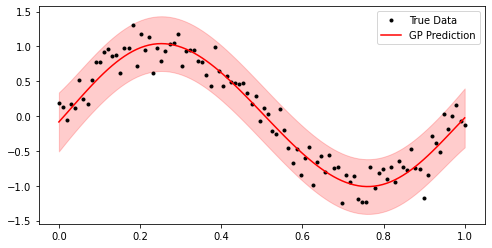

In [125]:
# 进行预测
model.eval()
likelihood.eval()

train_x = torch.linspace(0, 1, 100)
train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)
with torch.no_grad():
    observed_pred = likelihood(model(train_x))

# 绘制结果
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(train_x, train_y, 'k.', label='True Data')
ax.plot(train_x.numpy(), observed_pred.mean.numpy(), 'r', label='GP Prediction')
ax.fill_between(train_x.numpy(), 
                observed_pred.mean.numpy() - 1.96 * observed_pred.stddev.numpy(),
                observed_pred.mean.numpy() + 1.96 * observed_pred.stddev.numpy(), 
                alpha=0.2, color='red')
ax.legend()
plt.show()

In [36]:
import os
import time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold, train_test_split

from utils import get_one_fitness, LargeScenario

def str_to_timestamp(time_str, format="%Y-%m-%d|%H:%M:%S"):
    return time.mktime(time.strptime(time_str[:19], "%Y-%m-%d|%H:%M:%S"))

def filt_folders(folders, start_time, end_time):
    start_timestamp =  str_to_timestamp(start_time)
    end_timestamp =  str_to_timestamp(end_time)
    result = []
    for folder in folders:
        if str_to_timestamp(folder) >= start_timestamp and str_to_timestamp(folder) <= end_timestamp:
            result.append(folder)
    return result

def load_data(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    # root = '/home/guannan/Projects/SBT-data/InterFuser'
    folders = os.listdir(root)
    folders.sort()
    folders = filt_folders(folders, start, end)

    fitnesses = []
    scenarios = []

    for folder in folders:
        path = "{}/{}/".format(root, folder)
        # print(path)
        fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
        scenarios.append(LargeScenario(path))
    
    X = np.array([])
    for scenario in scenarios:
        if len(X) == 0:
            X = scenario.data
        else:
            X = np.concatenate([X, scenario.data], axis=0)

    y = np.array([])
    for fitnesse in fitnesses:
        print(y, fitnesse)
        if len(y) == 0:
            y = fitnesse
        else:
            y = np.concatenate([y, fitnesse], axis=0)
        print(y)
    return X, y


# 定义小型神经网络
class SmallNet(nn.Module):
    def __init__(self, input_dim):
        super(SmallNet, self).__init__()
        self.fc_64   = nn.Linear(input_dim, 64) # 第一层，全连接
        self.relu    = nn.ReLU()                # ReLU 激活函数
        self.dropout = nn.Dropout(0.1)          # Dropout 防止过拟合
        self.fc_32   = nn.Linear(64, 32)        # 第二层，全连接
        self.fc_out  = nn.Linear(32, 1)         # 输出层，单个回归值

    def forward(self, x):
        x = self.fc_64(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc_32(x)
        x = self.relu(x)

        x = self.fc_out(x)
        return torch.sigmoid(x)  # 输出值在 0-1 范围内

# 自定义加权损失函数
def weighted_mse_loss(output, target):
    # y=0 的样本权重更高
    weights = torch.where(target == 0, 5.0, 1.0)
    # weights = torch.where(target < 0.1, (1-target)*10, 1.0)
    # weights = torch.where(target < 0.5, 1-target, target)
    # weights = torch.where(target < 0.1, 1.0, 1.0)
    loss = weights * (output - target) ** 2
    return loss.mean()

def pairwise_rank_loss(output, target):
    # 计算目标值和预测值的差
    diff_target = target - target.T  # Target 的差
    diff_output = output - output.T  # Output 的差

    # 计算排序损失：如果 diff_target 和 diff_output 符号不一致，则 penalize
    loss = torch.mean(torch.relu(-diff_target * diff_output))  # relu 确保非负
    return loss

def combined_loss(output, target):
    weights = [10,0]
    return (weights[0]*weighted_mse_loss(output, target) + weights[1]*pairwise_rank_loss(output, target))/sum(weights)


def train(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    X, y = load_data(root, start, end)
    # 数据集（占位）
    # 使用你的数据，替换 X 和 y
    # X: shape = (num_samples, 71), y: shape = (num_samples,)
    X = X.astype(np.float32)  # 随机生成特征
    y = y.astype(np.float32)  # 随机生成标签

    # 转换为 PyTorch 张量
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y).view(-1, 1)

    # 超参数
    input_dim = X.shape[1]
    batch_size = 16
    num_epochs = 100
    learning_rate = 0.001

    # K 折交叉验证
    kf = KFold(n_splits=5)
    fold_mse = []


    X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.33, random_state=42)
    # for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        # print(f"Fold {fold + 1}")
        
        # # 划分训练集和验证集
        # X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
        # y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
        
    # 数据加载器
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化模型、损失函数和优化器
    model = SmallNet(input_dim=input_dim)
    # criterion = weighted_mse_loss
    # criterion = pairwise_rank_loss
    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 训练模型
    best_val_loss = float('inf')
    best_val_mse_loss = float('inf')
    early_stop_counter = 0
    patience = 10
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证模型
        model.eval()
        val_loss = 0.0
        val_mse_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_mse_loss += weighted_mse_loss(outputs, y_batch).item()
        
        val_loss /= len(val_loader)
        val_mse_loss /= len(val_loader)
        # print(f"Epoch {epoch + 1}: Train Loss = {train_loss / len(train_loader):.4f}, Val Loss = {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mse_loss = val_mse_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                # print("Early stopping triggered!")
                break
    
    # 保存每折的验证损失
    # fold_mse.append(best_val_loss)
    fold_mse.append(best_val_mse_loss)

    # 打印结果
    print("MSE:", np.mean(fold_mse))
    print("RMSE:", np.mean(fold_mse)**0.5)
    print(np.concatenate([np.array(outputs), np.array(y_batch)], axis=1))

    return model

In [37]:
train(root  = '/home/guannan/Projects/SBT-data/InterFuser', 
        start = '2025-02-16|21:00:00', 
        end   = '2025-02-28|09:30:00')

[] [0.         0.39527836 0.59469849 0.56612402 0.4317973  0.
 0.         0.4092145  0.43573922 0.59230214 0.46136758 0.54644752
 0.50797433 0.47180668 0.50978875 0.54469728 0.42254677 0.
 0.48734632 0.        ]
[0.         0.39527836 0.59469849 0.56612402 0.4317973  0.
 0.         0.4092145  0.43573922 0.59230214 0.46136758 0.54644752
 0.50797433 0.47180668 0.50978875 0.54469728 0.42254677 0.
 0.48734632 0.        ]
[0.         0.39527836 0.59469849 0.56612402 0.4317973  0.
 0.         0.4092145  0.43573922 0.59230214 0.46136758 0.54644752
 0.50797433 0.47180668 0.50978875 0.54469728 0.42254677 0.
 0.48734632 0.        ] [0.         0.40147436]
[0.         0.39527836 0.59469849 0.56612402 0.4317973  0.
 0.         0.4092145  0.43573922 0.59230214 0.46136758 0.54644752
 0.50797433 0.47180668 0.50978875 0.54469728 0.42254677 0.
 0.48734632 0.         0.         0.40147436]
MSE: 0.13757510483264923
RMSE: 0.37091118186521316
[[0.28246525 0.        ]
 [0.23896652 0.47180668]
 [0.25892013 0

SmallNet(
  (fc_64): Linear(in_features=71, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_32): Linear(in_features=64, out_features=32, bias=True)
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
)

In [5]:
root  = '/home/guannan/Projects/SBT-data/InterFuser'
start = '2025-02-26|21:00:00'
end   = '2025-02-28|09:30:00'

In [6]:
X, y = load_data(root, start, end)

In [8]:
X.shape

(2, 71)

In [9]:
y.shape

(2,)

In [23]:
folders = os.listdir(root)
folders.sort()
folders = filt_folders(folders, start, end)

fitnesses = []
scenarios = []

for folder in folders:
    path = "{}/{}/".format(root, folder)
    # print(path)
    fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
    scenarios.append(LargeScenario(path))

X = np.array([])
for scenario in scenarios:
    if len(X) == 0:
        X = scenario.data
    else:
        X = np.concatenate([X, scenario.data], axis=0)

y = np.array([])
for fitnesse in fitnesses:
    print(y, fitnesse)
    if len(y) == 0:
        y = fitnesse
    else:
        y = np.concatenate([y, fitnesse], axis=0)
    print(y)

[] [0.         0.40147436]
[0.         0.40147436]


In [24]:
scenario

In [26]:
y

array([0.        , 0.40147436])

In [10]:
y

In [4]:
import numpy as np
gen = 0
x = 0.1*gen+0.1
print("Generation:", gen+1)
# 固定前11个元素（所有行都一样）
fixed_11 = np.random.uniform(0, 1, 11)

# 存储所有数据的数组 (10, 71)
data = np.zeros((10, 71))
data[:, :11] = fixed_11  # 前11列一致

# 生成后60个满足均值为 x 的向量
for i in range(10):
    while True:
        random_59 = np.random.uniform(0, 1, 59)
        last_value = 60 * x - np.sum(random_59)
        if 0 <= last_value <= 1:
            row_60 = np.append(random_59, last_value)
            np.random.shuffle(row_60)  # 打乱，避免最后一个总是特殊
            data[i, 11:] = row_60
            break  # 合法就结束当前行的生成
        
print(data.shape)  # 输出：(10, 71)
print(data[:, :11])  # 所有行前11列一样
print(np.mean(data[:, 11:], axis=1))  # 每行后60列的均值约为0.6

Generation: 1


KeyboardInterrupt: 

In [11]:
random_60 = np.random.uniform(0, 1, (10,60))

In [ ]:
random_59 = np.random.uniform(0, 1, (10,59))
last_value = 60 * x - np.sum(random_59, axis=1)

array([-19.99579578, -22.78949156, -21.08903663, -23.43901545,
       -20.25983305, -25.89719221, -20.22687456, -26.06378075,
       -24.96242347, -22.92978275])

In [ ]:
x/random_60.mean(axis=1)

array([0.21854652, 0.19853864, 0.20014667, 0.20070532, 0.17095608,
       0.19333919, 0.18941027, 0.25186253, 0.18796076, 0.19927417])

In [26]:
np.multiply(random_60, x/random_60.mean(axis=1).reshape(-1, 1)).max()

0.24271482243708073

In [27]:
x = 0.1*gen+0.1
print("Generation:", gen+1)
# 固定前11个元素（所有行都一样）
fixed_11 = np.random.uniform(0, 1, 11)

# 存储所有数据的数组 (10, 71)
data = np.zeros((10, 71))
data[:, :11] = fixed_11  # 前11列一致

Generation: 1


In [33]:
data[:, 11:] = np.multiply(random_60, x/random_60.mean(axis=1).reshape(-1, 1))
print(data.shape)  # 输出：(10, 71)
print(data[:, :11])  # 所有行前11列一样
print(np.mean(data[:, 11:], axis=1))  # 每行后60列的均值约为0.6

(10, 71)
[[0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.20341637 0.26679955]
 [0.89786328 0.33172117 0.82816891 0.71031852 0.27422405 0.98297397
  0.90852935 0.83897072 0.79932828 0.2034

In [ ]:
random_60 = np.random.uniform(0, 1, (10,60))
last_value = 60 * x - np.sum(random_60, axis=1)

array([[0.03570504, 0.21826312, 0.52577725, 0.84453884, 0.60625482,
        0.95280325, 0.92532034, 0.57598844, 0.19390626, 0.68621881,
        0.19834201, 0.56172275, 0.52495655, 0.78431986, 0.16315024,
        0.34020469, 0.70065289, 0.8895274 , 0.52304269, 0.23713067,
        0.71050464, 0.7113454 , 0.42226402, 0.33930122, 0.93604819,
        0.174225  , 0.61352089, 0.32571292, 0.59216014, 0.70946478,
        0.16777449, 0.04516807, 0.9003547 , 0.58725835, 0.82775225,
        0.45646854, 0.03694687, 0.07227087, 0.29816758, 0.87123493,
        0.17431316, 0.12656724, 0.09019866, 0.22540371, 0.35860163,
        0.53759779, 0.31167603, 0.98712475, 0.00419703, 0.6014602 ,
        0.80717389, 0.067918  , 0.37030502, 0.16998099, 0.19420846,
        0.00357016, 0.11652915, 0.43528985, 0.67877644, 0.90744667],
       [0.169687  , 0.38262143, 0.49762118, 0.60959162, 0.62231627,
        0.46515175, 0.0425297 , 0.54538412, 0.05757995, 0.71642293,
        0.12810153, 0.15695395, 0.96424774, 0.3

In [1]:
if False:
    print(3)
else:
    print(4)

4


In [28]:
random_60 = np.random.uniform(1, 2, (n_samples,60))

In [31]:
random_60/random_60.mean(axis=1)

ValueError: operands could not be broadcast together with shapes (20,60) (20,) 

In [30]:
random_60.mean(axis=1)

array([1.46914534, 1.50884751, 1.50964975, 1.47847834, 1.4756355 ,
       1.58943598, 1.44137504, 1.553747  , 1.49525135, 1.49974686,
       1.50793922, 1.48919766, 1.51034993, 1.45532345, 1.46715864,
       1.50353421, 1.56747797, 1.54135524, 1.55441232, 1.50899176])

In [57]:
import numpy as np

n_samples = 20
n_var = 71

X = np.zeros((n_samples, n_var))
target_means = np.linspace(0.1, 1.0, num=n_samples)
for i in range(n_samples):
    X[i, :11] = np.random.uniform(0, 1, 11)  # 前11列一致

    random_60 = np.random.uniform(20, 21, 60)
    random_60 = random_60 * target_means[i] / random_60.mean()
    X[i, 11:] = np.clip(random_60, 0, 1)
    # X[i, 11:] = random_60

In [58]:
i, random_60

(19,
 array([0.9817803 , 0.98976462, 0.98758482, 0.982375  , 0.98041431,
        0.99648824, 1.02224241, 1.00261097, 1.00402831, 0.98892055,
        1.02408566, 0.99063629, 1.00639142, 1.00237589, 0.98231167,
        1.00127737, 1.01885253, 0.99541136, 1.01541024, 1.01610241,
        0.98615955, 0.98997517, 0.99982885, 0.99157347, 1.00410521,
        0.98358403, 0.98369967, 0.99676906, 1.00653228, 0.98985367,
        1.02608001, 1.01117562, 1.01683801, 0.99346882, 0.98755827,
        1.01713992, 0.99325797, 0.98260311, 1.01137482, 0.99004514,
        1.00542798, 0.9879536 , 1.00282349, 1.00186179, 0.99432587,
        1.02610553, 0.99949173, 1.00653646, 0.98013144, 1.00250976,
        1.01840373, 0.99253885, 1.00160488, 1.012535  , 1.01869633,
        1.01925224, 1.02387082, 0.98309932, 0.98462891, 0.98751525]))

In [59]:
X[:, 11:].mean(axis=1)

array([0.1       , 0.14736842, 0.19473684, 0.24210526, 0.28947368,
       0.33684211, 0.38421053, 0.43157895, 0.47894737, 0.52631579,
       0.57368421, 0.62105263, 0.66842105, 0.71578947, 0.76315789,
       0.81052632, 0.85789474, 0.90526316, 0.95263158, 0.99422915])

In [44]:
X[:, 11:]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04179691, 0.04125321, 0.06550044, ..., 0.05151654, 0.05344091,
        0.04781786],
       [0.10884688, 0.09701042, 0.09052549, ..., 0.10068951, 0.12506682,
        0.13658887],
       ...,
       [0.83566158, 0.84803451, 0.89518021, ..., 0.85054295, 0.67662636,
        0.97477732],
       [1.        , 0.85391979, 0.66652222, ..., 1.        , 1.        ,
        0.69834311],
       [0.74087903, 1.        , 0.93892465, ..., 0.77805567, 1.        ,
        0.97467264]])

In [27]:
random_60

array([1.18019089, 1.35732993, 1.93045092, 1.10151238, 1.975976  ,
       1.69698251, 1.16188714, 1.58153027, 1.69730801, 1.79041872,
       1.37831723, 1.77924964, 1.19474648, 1.37739726, 1.02407605,
       1.06729342, 1.36076653, 1.49791959, 1.31613057, 1.58817728,
       1.69501916, 1.52918706, 1.95990938, 1.61989288, 1.48110161,
       1.19512381, 1.08865998, 1.56105386, 1.39820164, 1.27015636,
       1.492223  , 1.26469928, 1.07670106, 1.68559931, 1.87121895,
       1.32195093, 1.11221357, 1.45540993, 1.74902826, 1.8157312 ,
       1.11187187, 1.37538641, 1.86724445, 1.85705659, 1.11639141,
       1.22690424, 1.61644961, 1.67267907, 1.9012563 , 1.59631317,
       1.00138677, 1.53073108, 1.08787127, 1.23999362, 1.58763349,
       1.09473239, 1.83988078, 1.89867486, 1.30118054, 1.81728442])

In [31]:
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.core.sampling import Sampling
from pymoo.core.problem import Problem
import numpy as np


class AverageSampling(Sampling):
    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, problem.n_var))
        target_means = np.linspace(0.1, 1.0, num=n_samples)
        for i in range(n_samples):
            X[i, :11] = np.random.uniform(0, 1, 11)  # 前11列一致

            random_60 = np.random.uniform(20, 21, 60)
            random_60 = random_60 * target_means[i] / random_60.mean()
            X[i, 11:] = np.clip(random_60, 0, 1)
        return X  # 返回自定义种群

In [32]:
n_samples = 20
problem = Problem(n_var=71, n_obj=2, n_constr=0, xl=0, xu=1)

In [33]:
sampler = AverageSampling()
samples = sampler._do(problem=problem, n_samples=n_samples)
print(np.linspace(0.1, 1.0, num=n_samples))
print(samples[:,11:].mean(axis=1))


[0.1        0.14736842 0.19473684 0.24210526 0.28947368 0.33684211
 0.38421053 0.43157895 0.47894737 0.52631579 0.57368421 0.62105263
 0.66842105 0.71578947 0.76315789 0.81052632 0.85789474 0.90526316
 0.95263158 1.        ]
[0.1        0.14736842 0.19473684 0.24210526 0.28947368 0.33684211
 0.38421053 0.43157895 0.47894737 0.52631579 0.57368421 0.62105263
 0.66842105 0.71578947 0.76315789 0.81052632 0.85789474 0.90526316
 0.95263158 0.993276  ]


In [35]:
sampler = FloatRandomSampling()
samples = sampler._do(problem=problem, n_samples=20)
print(np.linspace(0.1, 1.0, num=n_samples))
print(samples[:,11:].mean(axis=1))

[0.1        0.14736842 0.19473684 0.24210526 0.28947368 0.33684211
 0.38421053 0.43157895 0.47894737 0.52631579 0.57368421 0.62105263
 0.66842105 0.71578947 0.76315789 0.81052632 0.85789474 0.90526316
 0.95263158 1.        ]
[0.54720045 0.54628579 0.52733087 0.47446801 0.50689859 0.41774506
 0.51654337 0.49368986 0.47170616 0.47830383 0.45533929 0.55137705
 0.51096347 0.52937065 0.51902892 0.45322443 0.45720024 0.45706753
 0.45592376 0.51356083]


In [20]:
import argparse
import os
import numpy as np
def parse_fuzzing_arguments(argv=None):
# def parse_fuzzing_arguments():
    
    # [ego_linear_speed, min_d, d_angle_norm, offroad_d, wronglane_d, dev_dist, is_offroad, is_wrong_lane, is_run_red_light, is_collision]
    default_objective_weights = np.array([-1., 1., 1., 1., 1., -1., 0., 0., 0., 0.])
    default_objectives = np.array([0., 20., 1., 7., 7., 0., 0., 0., 0., 0.])
    default_check_unique_coeff = [0, 0.1, 0.5]


    parser = argparse.ArgumentParser()

    # general
    parser.add_argument("-r", "--route_type", type=str, default='town05_right_0')
    parser.add_argument("-c", "--scenario_type", type=str, default='default')
    parser.add_argument("-m", "--ego_car_model", type=str, default='lbc')
    parser.add_argument('-a','--algorithm_name', type=str, default='nsga2')

    parser.add_argument('-p','--ports', nargs='+', type=int, default=[2003], help='TCP port(s) to listen to (default: 2003)')
    parser.add_argument("-s", "--scheduler_port", type=int, default=8785)
    parser.add_argument("-d", "--dashboard_address", type=int, default=8786)

    parser.add_argument('--simulator', type=str, default='carla')

    parser.add_argument('--random_seed', type=int, default=0)


    # carla specific
    parser.add_argument("--has_display", type=str, default='0')
    parser.add_argument("--debug", type=int, default=1, help="whether using the debug mode: planned paths will be visualized.")
    parser.add_argument('--correct_spawn_locations_after_run', type=int, default=0)

    # carla_op specific
    parser.add_argument('--carla_path', type=str, default="../carla_0911_rss/CarlaUE4.sh")

    # no_simulation specific
    parser.add_argument('--no_simulation_data_path', type=str, default=None)
    parser.add_argument('--objective_labels', type=str, nargs='+', default=[])



    # logistic
    parser.add_argument("--root_folder", type=str, default='carla_lbc/run_results')
    parser.add_argument("--parent_folder", type=str, default='') # will be automatically created
    parser.add_argument("--mean_objectives_across_generations_path", type=str, default='') # will be automatically created
    parser.add_argument("--episode_max_time", type=int, default=60)
    parser.add_argument('--record_every_n_step', type=int, default=2000)
    parser.add_argument('--gpus', type=str, default='0,1')


    # algorithm related
    parser.add_argument("--n_gen", type=int, default=2)
    parser.add_argument("--pop_size", type=int, default=50)
    parser.add_argument("--survival_multiplier", type=int, default=1)
    parser.add_argument("--n_offsprings", type=int, default=300)
    parser.add_argument("--has_run_num", type=int, default=1000)
    parser.add_argument('--sample_multiplier', type=int, default=200)
    parser.add_argument('--mating_max_iterations', type=int, default=200)
    parser.add_argument('--only_run_unique_cases', type=int, default=1)
    parser.add_argument('--consider_interested_bugs', type=int, default=1)

    parser.add_argument("--outer_iterations", type=int, default=3)
    parser.add_argument('--objective_weights', nargs='+', type=float, default=default_objective_weights)
    parser.add_argument('--default_objectives', nargs='+', type=float, default=default_objectives)
    parser.add_argument("--standardize_objective", type=int, default=0)
    parser.add_argument("--normalize_objective", type=int, default=0)
    parser.add_argument('--traj_dist_metric', type=str, default='nearest')



    parser.add_argument('--check_unique_coeff', nargs='+', type=float, default=default_check_unique_coeff)
    parser.add_argument('--use_single_objective', type=int, default=1)
    parser.add_argument('--rank_mode', type=str, default='none')
    parser.add_argument('--ranking_model', type=str, default='nn_pytorch')
    parser.add_argument('--initial_fit_th', type=int, default=100, help='minimum number of instances needed to train a DNN.')
    parser.add_argument('--min_bug_num_to_fit_dnn', type=int, default=10, help='minimum number of bug instances needed to train a DNN.')

    parser.add_argument('--pgd_eps', type=float, default=1.01)
    parser.add_argument('--adv_conf_th', type=float, default=-4)
    parser.add_argument('--attack_stop_conf', type=float, default=0.9)
    parser.add_argument('--use_single_nn', type=int, default=1)

    parser.add_argument('--warm_up_path', type=str, default=None)
    parser.add_argument('--warm_up_len', type=int, default=-1)
    parser.add_argument('--regression_nn_use_running_data', type=int, default=1)

    parser.add_argument('--sample_avoid_ego_position', type=int, default=0)


    parser.add_argument('--uncertainty', type=str, default='')
    parser.add_argument('--model_type', type=str, default='one_output')


    parser.add_argument('--termination_condition', type=str, default='generations')
    parser.add_argument('--max_running_time', type=int, default=3600*24)

    parser.add_argument('--emcmc', type=int, default=0)
    parser.add_argument('--use_unique_bugs', type=int, default=1)
    parser.add_argument('--finish_after_has_run', type=int, default=1)

    # fuzzing_arguments = parser.parse_args()

        # parse either from provided argv list (programmatic) or from CLI
    if argv is None:
        fuzzing_arguments = parser.parse_args()
    else:
        fuzzing_arguments = parser.parse_args(argv)


    os.environ['HAS_DISPLAY'] = fuzzing_arguments.has_display
    os.environ['CUDA_VISIBLE_DEVICES'] = fuzzing_arguments.gpus
    fuzzing_arguments.objective_weights = np.array(fuzzing_arguments.objective_weights)
    # ['BNN', 'one_output']
    # BALD and BatchBALD only support BNN
    if fuzzing_arguments.uncertainty.split('_')[0] in ['BALD', 'BatchBALD']:
        fuzzing_arguments.model_type = 'BNN'

    if 'un' in fuzzing_arguments.algorithm_name:
        fuzzing_arguments.use_unique_bugs = 1
    else:
        fuzzing_arguments.use_unique_bugs = 0

    if fuzzing_arguments.algorithm_name in ['nsga2-emcmc', 'nsga2-un-emcmc']:
        fuzzing_arguments.emcmc = 1
    else:
        fuzzing_arguments.emcmc = 0

    return fuzzing_arguments

In [21]:
argv = [
    "-p", "2018",
    "-s", "8793",
    "-d", "8794",
    "-r", "town07_front_0",
    "-c", "go_straight_town07",

    "--n_gen", "200",
    "--pop_size", "4",
    "--algorithm_name", "avfuzzer",
    "--has_run_num", "700",
    "--has_display", "0",
    "--n_offsprings", "50",

    "--record_every_n_step", "5",
    "--only_run_unique_cases", "0",

    "--objective_weights", "-1", "1", "1", "0", "0", "0", "0", "0", "0", "0",
    "--check_unique_coeff", "0", "0.1", "0.5"
]

In [1]:
import numpy as np

data = np.load('/home/guannan/Projects/TCP-Interfuser/leaderboard/leaderboard/SBT/unique_failures.npy', allow_pickle=True)

In [8]:
for i in range(data.shape[0]//10+1):
    print(i*10, (i+1)*10)
    print(data[i*10:(i+1)*10])

0 10
[[0.568 0.858 0.742 0.46  0.711 0.066 0.222 0.806 0.989 0.089 0.792 0.371
  0.952 0.605 0.999 0.614 0.534 0.546 0.021 0.644 0.56  0.924 0.195 0.618
  0.648 0.394 0.455 0.765 0.551 0.233 0.687 0.399 0.769 0.652 0.808 0.235
  0.127 0.65  0.046 0.98  0.616 0.608 0.509 0.922 0.646 0.431 0.383 0.848
  0.197 0.386 0.083 0.766 0.969 0.656 0.43  0.207 0.769 0.849 0.458 0.595
  0.974 0.11  0.876 0.209 0.53  0.075 0.859 0.398 0.915 0.696 0.445]
 [0.272 0.024 0.663 0.516 0.231 0.994 0.683 0.533 0.746 0.117 0.12  0.135
  0.657 0.716 0.639 0.348 0.425 0.342 0.02  0.713 0.481 0.401 0.956 0.647
  0.465 0.724 0.043 0.093 0.388 0.085 0.992 0.206 0.834 0.814 0.731 0.791
  0.527 0.173 0.726 0.89  0.629 0.226 0.433 0.714 0.391 0.051 0.111 0.04
  0.302 0.748 0.508 0.981 0.453 0.287 0.967 0.187 0.093 0.599 0.83  0.424
  0.627 0.168 0.173 0.833 0.224 0.135 0.16  0.351 0.473 0.12  0.431]
 [0.991 0.238 0.084 0.709 0.443 0.758 0.766 0.746 0.562 0.298 0.381 0.124
  0.687 0.615 0.149 0.285 0.248 0.393 0.117 

In [ ]:
parse_fuzzing_arguments(argv)

Namespace(adv_conf_th=-4, algorithm_name='avfuzzer', attack_stop_conf=0.9, carla_path='../carla_0911_rss/CarlaUE4.sh', check_unique_coeff=[0.0, 0.1, 0.5], consider_interested_bugs=1, correct_spawn_locations_after_run=0, dashboard_address=8794, debug=1, default_objectives=array([ 0., 20.,  1.,  7.,  7.,  0.,  0.,  0.,  0.,  0.]), ego_car_model='lbc', emcmc=0, episode_max_time=60, finish_after_has_run=1, gpus='0,1', has_display='0', has_run_num=700, initial_fit_th=100, mating_max_iterations=200, max_running_time=86400, mean_objectives_across_generations_path='', min_bug_num_to_fit_dnn=10, model_type='one_output', n_gen=200, n_offsprings=50, no_simulation_data_path=None, normalize_objective=0, objective_labels=[], objective_weights=array([-1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]), only_run_unique_cases=0, outer_iterations=3, parent_folder='', pgd_eps=1.01, pop_size=4, ports=[2018], random_seed=0, rank_mode='none', ranking_model='nn_pytorch', record_every_n_step=5, regression_nn_u

: 

In [20]:
def elementwise_similarity(x,y,threshold=0.1):
    similarity = np.zeros((x.shape[0], y.shape[0]))
    for i, s1 in enumerate(x):
        for j, s2 in enumerate(y):
            similarity[i, j] = ((s2-s1)**2 < threshold**2).mean()
    return similarity

def _similarity(simi_func, fail, x):
    if fail.shape[0] == 0:
        return np.array([0]*len(x))
    else:
        print(simi_func(np.array(fail), np.array(x)))
        return simi_func(np.array(fail), np.array(x)).max(axis=0)

In [29]:
0.1970831*10000 %2

0.831000000000131

In [44]:
import numpy as np
fail_cases = []


for i in range(20):

    x = np.random.rand(10,71)

    fitness = (x*10000%2>1).sum(axis=1) 


    similarity = _similarity(elementwise_similarity, np.array(fail_cases), np.array(x))

    fail_cases += x[similarity<0.5 and fitness].tolist()

    print(similarity, len(x[similarity<0.5]), len(fail_cases))


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [38]:
fitness

array([False, False, False,  True,  True,  True, False,  True, False,
        True])

In [41]:
similarity<0.5

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [46]:
similarity<0.5 * (fitness> 35)

array([ True,  True,  True,  True, False,  True, False,  True, False,
        True])

In [34]:
fitness

array([[ True, False,  True,  True, False,  True,  True, False, False,
         True, False, False,  True,  True,  True,  True,  True, False,
         True,  True,  True,  True, False, False, False,  True,  True,
         True,  True,  True,  True, False, False, False,  True, False,
        False, False,  True, False,  True,  True, False,  True, False,
        False, False,  True,  True,  True, False, False,  True,  True,
         True, False, False,  True, False,  True,  True, False,  True,
         True, False, False, False, False, False,  True, False],
       [ True,  True,  True, False,  True, False, False,  True, False,
         True,  True, False,  True, False,  True,  True,  True, False,
         True,  True,  True, False,  True,  True,  True, False,  True,
        False, False,  True,  True, False,  True,  True,  True,  True,
         True, False,  True,  True, False,  True, False, False, False,
        False, False,  True, False, False,  True, False, False,  True,
        Fals

In [31]:
fitness

array([[False,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False,  True, False, False, False,  True,
         True, False,  True,  True,  True, False,  True,  True,  True,
        False,  True, False,  True, False,  True,  True, False, False,
         True,  True, False,  True, False, False,  True, False,  True,
        False, False,  True,  True, False, False, False, False,  True,
        False,  True, False, False, False,  True, False,  True,  True,
         True, False, False,  True,  True, False,  True,  True],
       [False, False, False, False, False, False,  True,  True, False,
         True, False,  True, False,  True, False,  True,  True,  True,
        False,  True,  True,  True,  True,  True,  True, False,  True,
        False,  True,  True,  True, False,  True,  True, False,  True,
         True, False,  True,  True, False,  True,  True, False,  True,
         True,  True,  True, False,  True, False,  True,  True,  True,
        Fals

In [19]:
np.array(fail_cases)

array([[3.41358850e-01, 7.68018937e-03, 3.14430578e-01, ...,
        8.33929296e-01, 5.56297454e-01, 7.47032002e-01],
       [5.87615551e-01, 4.69329147e-01, 8.96605909e-01, ...,
        5.93777650e-01, 2.89085108e-01, 2.46112751e-02],
       [5.87222861e-01, 3.76660782e-01, 9.60214328e-01, ...,
        6.28233389e-01, 5.70969279e-01, 7.32438008e-01],
       ...,
       [6.64719545e-03, 8.05465557e-01, 6.08946371e-01, ...,
        2.17091354e-02, 7.48407390e-01, 4.13311852e-01],
       [8.64738499e-01, 3.44481104e-01, 6.41796859e-01, ...,
        8.57337352e-01, 4.19536724e-02, 8.94448539e-01],
       [7.63690367e-01, 4.08767568e-01, 1.96296994e-04, ...,
        1.43628245e-01, 8.77032574e-01, 2.48521056e-01]])

In [18]:
x

array([[9.86234118e-01, 4.93331894e-01, 2.15060701e-01, 4.60440610e-01,
        7.42618588e-01, 8.08798482e-01, 3.71212557e-01, 1.61667057e-01,
        2.14760346e-01, 4.75606132e-01, 9.62253062e-01, 6.01029207e-01,
        6.56727130e-01, 5.08739185e-01, 7.81213584e-01, 7.26904444e-01,
        8.87721389e-01, 4.18239995e-01, 2.30656932e-01, 7.91205139e-01,
        5.91937989e-01, 9.17747197e-01, 9.57740850e-01, 5.05210071e-01,
        5.34596982e-01, 1.06184249e-01, 7.85455195e-01, 5.10306224e-01,
        9.12497405e-01, 6.91840447e-01, 9.86281533e-01, 7.47962381e-01,
        9.44871643e-02, 1.53714094e-01, 5.13733234e-01, 3.03245263e-01,
        3.26096028e-01, 3.23579038e-01, 9.72558500e-02, 8.95867850e-01,
        3.27167626e-01, 4.54028917e-01, 6.50394705e-01, 5.79812159e-01,
        4.31516181e-01, 9.26191495e-01, 7.18399045e-03, 3.06904180e-01,
        7.62005944e-01, 2.06416073e-01, 7.92648716e-01, 9.91346071e-01,
        3.16984522e-01, 5.32926155e-01, 8.36709483e-01, 4.902257

In [ ]:
import numpy as np
fail_cases = np.random.rand(5,71)

x = np.random.rand(5,71)

similarity = _similarity(elementwise_similarity, np.array(fail_cases), np.array(x))

similarity


array([0.25352113, 0.23943662, 0.23943662, 0.26760563, 0.23943662])